In [ ]:
!pip install kaggle

In [1]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
#

Mounted at /content/drive


In [2]:
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv("/content/drive/MyDrive/Python/cicids2017_cleaned.csv")

df['Traffic_Type'] = df['Attack Type'].apply(
    lambda x: 'Normal' if x == 'Normal Traffic' else 'Attack'
)

print(f'Shape: {df.shape}')
print(f'\nAttack Type counts:')
print(df['Attack Type'].value_counts())

Shape: (2520751, 54)

Attack Type counts:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [ ]:

# =============================================================
# LINEAR REGRESSION
# Goal: Predict Flow Duration from network traffic features
# Note: Regression can't classify attacks directly — it predicts
# a continuous number. We use it to show attack traffic behaves
# differently even without a classifier.
# =============================================================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
# Features selected based on EDA findings
# These 7 features showed the strongest separation between normal and attack traffic

features = ['Flow Packets/s',          # packet rate — high in scans, low in slow attacks
            'Flow Bytes/s',            # throughput — highest in normal traffic
            'Fwd Packet Length Mean',  # average forward packet size
            'Bwd Packet Length Mean',  # average backward packet size
            'ACK Flag Count',          # TCP acknowledgements — low in attack flows
            'Init_Win_bytes_forward',  # initial TCP window size — key attack indicator
            'Idle Mean']               # average idle time — correlated with flow duration

target = 'Flow Duration'  # what we are trying to predict (in microseconds)

# Remove zero-duration flows — these are single packet flows with no meaningful duration
# Keeping them would distort the regression since we can't predict duration of 0
data = df[df[target] > 0].copy().reset_index(drop=True)

X = data[features]  # feature matrix
y = data[target]    # target vector

print(f'Training data shape: {X.shape}')
print(f'\\nFeature summary:')
print(X.describe().round(2))

Training data shape: (2520644, 7)
\nFeature summary:
       Flow Packets/s  Flow Bytes/s  Fwd Packet Length Mean  \
count      2520644.00  2.520644e+06              2520644.00   
mean         47376.06  1.411261e+06                   63.50   
std         202225.25  2.657078e+07                  195.55   
min              0.02  0.000000e+00                    0.00   
25%              2.02  1.194400e+02                    6.00   
50%             69.77  3.715650e+03                   36.25   
75%          17857.14  1.071429e+05                   52.00   
max        4000000.00  2.071000e+09                 5940.86   

       Bwd Packet Length Mean  ACK Flag Count  Init_Win_bytes_forward  \
count              2520644.00      2520644.00              2520644.00   
mean                   340.63            0.31                 7265.63   
std                    632.54            0.46                14597.85   
min                      0.00            0.00                   -1.00   
25%           

In [ ]:
from sklearn.preprocessing import StandardScaler

# Split data into training and test sets
# test_size=0.2 — 80% for training, 20% for testing
# random_state=42 — ensures reproducibility, same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# WHY SCALING?
# Our features live on very different scales:
#   Flow Bytes/s can be in the billions
#   ACK Flag Count is just 0 or 1
# Linear Regression treats a "1 unit change" the same across all features
# That's unfair — 1 unit in bytes means nothing, 1 unit in ACK count means everything
# StandardScaler fixes this by pulling every feature to the same scale (mean=0, std=1)
# Think of it as converting everything to a common unit before comparing

scaler = StandardScaler()

# Fit and scale the training data
# scaler learns the mean and std from training data here
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data using the SAME mean and std learned from training
# We never fit on test data — we haven't "seen" it yet in real life
# Fitting on test data would be cheating — the model would look better than it really is
X_test_scaled = scaler.transform(X_test)

print(f'Training set : {X_train_scaled.shape}')
print(f'Test set     : {X_test_scaled.shape}')

Training set : (2016515, 7)
Test set     : (504129, 7)


In [ ]:
# Train
# Create and train the Linear Regression model
# lr.fit() is where the actual learning happens
# it finds the best straight line through the training data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
# Use the trained model to predict Flow Duration on unseen test data
y_pred = lr.predict(X_test_scaled)


# Evaluate
# EVALUATE — how good are the predictions?

# R² Score — how much of the variation in Flow Duration does the model explain?
# R² = 1.0 would mean perfect predictions
# R² = 0.0 means the model is no better than just guessing the average every time
# Our result of 0.61 means the model explains 61% of the variation — moderate

# Mean Absolute Error (MAE) — on average, how many microseconds off is each prediction?
# We convert to seconds to make it human readable
# Our result of 11.37 seconds means the model is off by 11 seconds on average
# In network terms that's a large error — regression alone isn't enough for IDS

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R² Score          : {r2:.4f}')
print(f'Mean Absolute Error: {mae:,.0f} microseconds')
print(f'                   : {mae/1e6:.2f} seconds')
# Coefficients — which features matter most
coef_df = pd.DataFrame({
'Feature': features,
'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(f'\nFeature Coefficients:')
print(coef_df.to_string(index=False))



R² Score          : 0.6113
Mean Absolute Error: 11,373,604 microseconds
                   : 11.37 seconds

Feature Coefficients:
               Feature   Coefficient
             Idle Mean  2.761857e+07
Init_Win_bytes_forward  4.761618e+06
        ACK Flag Count -2.195184e+06
Fwd Packet Length Mean  1.157505e+06
        Flow Packets/s -6.175151e+05
Bwd Packet Length Mean -4.558959e+05
          Flow Bytes/s -7.199318e+04


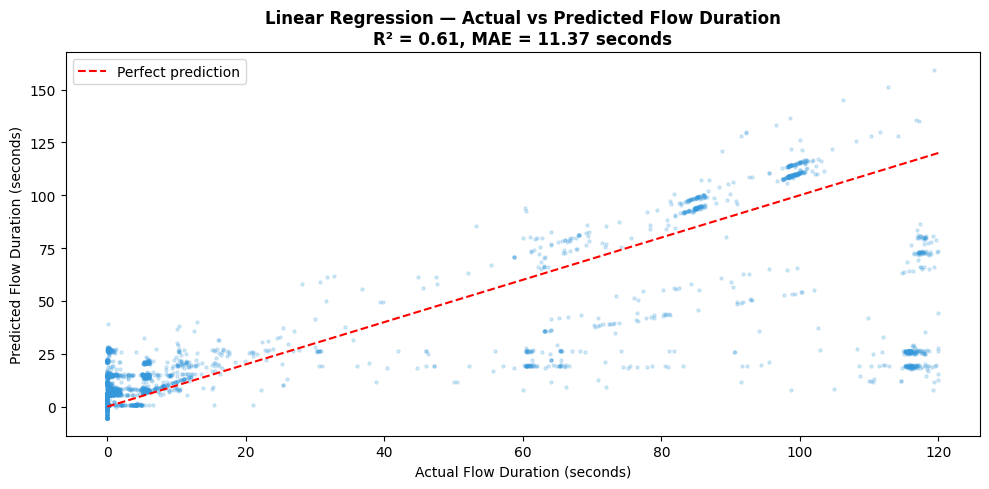

In [ ]:
# Sample for plotting
# VISUALISE — Actual vs Predicted Flow Duration
# Each dot = one network flow from the test set
# X axis = how long the flow actually lasted
# Y axis = how long the model predicted it would last
# A perfect model would have every dot sitting exactly on the red dashed line
# Dots above the line = model overestimated duration
# Dots below the line = model underestimated duration
# The scatter around the line shows where the model struggles

# Plotting 5000 random samples instead of all 500K test rows
# Full dataset would take too long to render and the pattern is the same
sample_idx = np.random.choice(len(y_test), 5000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]
y_pred_sample = y_pred[sample_idx]

plt.figure(figsize=(10, 5))
plt.scatter(y_test_sample/1e6, y_pred_sample/1e6,
            alpha=0.2, color='#3498db', s=5)

# The red dashed line = perfect predictions (actual == predicted)
# The further dots are from this line, the worse the prediction

plt.plot([0, y_test_sample.max()/1e6],
         [0, y_test_sample.max()/1e6],
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Flow Duration (seconds)')
plt.ylabel('Predicted Flow Duration (seconds)')
plt.title('Linear Regression — Actual vs Predicted Flow Duration\nR² = 0.61, MAE = 11.37 seconds',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('03_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Reset index on data before splitting
# Earlier we got an index error — filtering rows leaves gaps in row numbers
# reset_index(drop=True) gives us clean row numbers starting from 0

data = df[df[target] > 0].copy().reset_index(drop=True)

X = data[features]
y = data[target]

# Split and scale again with the clean data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain model on clean data
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

# Now this will work
test_data = X_test.copy()
test_data['Actual'] = np.array(y_test)
test_data['Predicted'] = y_pred
test_data['Traffic_Type'] = data.loc[X_test.index, 'Traffic_Type'].values

comparison = test_data.groupby('Traffic_Type')[['Actual', 'Predicted']].mean() / 1e6

# Difference shows how far off the model was for each traffic type
# Negative = model overestimated, Positive = model underestimated
comparison.columns = ['Actual Duration (s)', 'Predicted Duration (s)']
comparison['Difference (s)'] = (comparison['Actual Duration (s)'] -
                                  comparison['Predicted Duration (s)']).round(2)
comparison = comparison.round(2)

print('Model Performance by Traffic Type:')
print(comparison.to_string())

Model Performance by Traffic Type:
              Actual Duration (s)  Predicted Duration (s)  Difference (s)
Traffic_Type                                                             
Attack                      38.45                   44.21           -5.76
Normal                      12.19                   10.99            1.20


###Observations
Normal Traffic : Actual 12.19s | Predicted 10.99s | Difference 1.20s (underestimated)
Attack Traffic : Actual 38.45s | Predicted 44.21s | Difference -5.76s (overestimated)

The model predicts attack flows will last longer than they actually do.
It can sense attack traffic is different — but it cannot classify it.
That is the limit of Linear Regression for this problem.

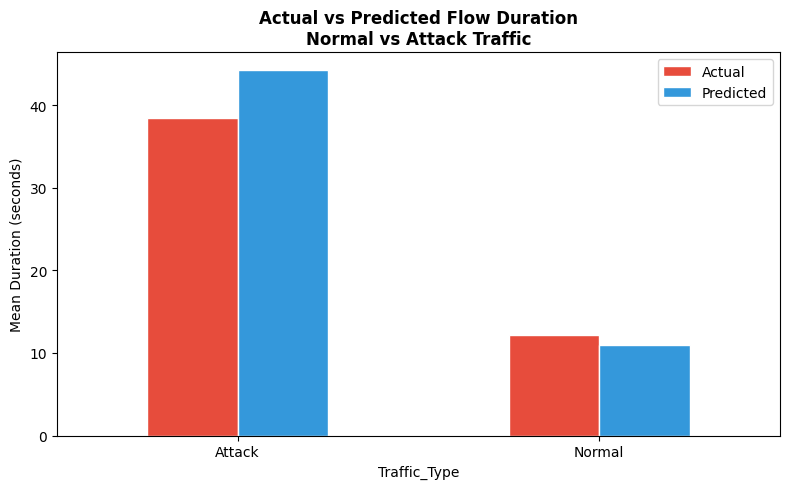

In [ ]:

# CHART — did the model predict Normal and Attack durations correctly?
# Red bar = what actually happened
# Blue bar = what the model predicted
# Closer the bars = better the prediction
comparison[['Actual Duration (s)', 'Predicted Duration (s)']].plot(
    kind='bar',
    color=['#e74c3c', '#3498db'],
    edgecolor='white',
    figsize=(8, 5)
)

plt.title('Actual vs Predicted Flow Duration\nNormal vs Attack Traffic',
          fontweight='bold')
plt.ylabel('Mean Duration (seconds)')
plt.xticks(rotation=0)
plt.legend(['Actual', 'Predicted'])
plt.tight_layout()
plt.savefig('03_lr_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()




###Observations
The model overestimates how long attack flows last and underestimates how long normal flows last. It knows something is different about attack traffic — it just can't say what. That's the limit of regression here

In [ ]:

# =============================================================
# DECISION TREES — asking the model to make a decision
# Regression told us attack traffic behaves differently
# but couldn't name it. Decision Trees can.
# It builds a series of yes/no questions from the data:
# "Is Init_Win_bytes_forward < 500? Yes → likely an attack"
# =============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df[features]
y = df['Attack Type']

# Train test split
# Split into training and test sets
# stratify=y is important here — it makes sure every attack type
# appears in both train and test sets proportionally
# without it, rare classes like Web Attacks might not appear in test at all
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set : (2016600, 7)
Test set     : (504151, 7)

Class distribution in training set:
Attack Type
Normal Traffic    1676045
DoS                154996
DDoS               102411
Port Scanning       72555
Brute Force          7320
Web Attacks          1714
Bots                 1559
Name: count, dtype: int64


In [ ]:

# Build the Decision Tree
# max_depth=5 — limits how deep the tree grows
# a deeper tree memorises the training data but fails on new data (overfitting)
# depth 5 keeps it simple enough to generalise and explain to a non-technical audience

# class_weight='balanced' — tells the model to pay extra attention to rare classes
# without this, the model ignores Web Attacks and Bots (less than 0.2% of data)
# and just predicts Normal Traffic for everything — looks good on paper, useless in a SOC

# random_state=42 — same result every time we run it
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

# Train the model — this is where it builds the yes/no decision rules
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree trained ✅')

# Compare training vs test accuracy
# if training accuracy is much higher than test — the model is overfitting
# similar scores mean the model generalises well to new data

print(f'\nTraining Accuracy : {dt.score(X_train, y_train):.4f}')
print(f'Test Accuracy     : {dt.score(X_test, y_test):.4f}')

NameError: name 'X_train' is not defined

###Observations
Training Accuracy : 66.71%
Test Accuracy     : 66.77%

Training and test accuracy are almost identical — the model is not overfitting.
It generalises well to new unseen traffic.


In [ ]:
# How well did the model do for each attack type?
# Accuracy alone doesn't tell the full story — this does

# Three numbers per class:
# Precision — when the model said "this is a DDoS", how often was it right?
# Recall    — out of all the real DDoS attacks, how many did the model catch?
# F1        — balance between the two, useful when both matter

# In security, Recall matters most
# Missing a real attack (low Recall) is worse than a false alarm (low Precision)
# A false alarm wastes an analyst's time
# A missed attack could mean a breach
print(classification_report(y_test, y_pred_dt))

                precision    recall  f1-score   support

          Bots       0.36      0.27      0.31       389
   Brute Force       0.08      0.77      0.15      1830
          DDoS       0.22      1.00      0.36     25603
           DoS       0.43      0.88      0.58     38749
Normal Traffic       0.99      0.61      0.76    419012
 Port Scanning       0.73      0.99      0.84     18139
   Web Attacks       0.06      0.90      0.12       429

      accuracy                           0.67    504151
     macro avg       0.41      0.77      0.45    504151
  weighted avg       0.89      0.67      0.72    504151



### Observations:
#
Good news — the model catches most attacks
* DDoS        : 100% caught — missed none
* Port Scan   : 99% caught
*  Web Attacks : 90% caught — great for such a rare class
*  DoS         : 88% caught
#
The problem — too many false alarms
* Web Attacks : only 6% precision — flags 15 innocent flows for every real attack
* Brute Force : only 8% precision — same issue
* DDoS        : 22% precision — catches everything but raises too many false alerts
#
Think of it like a car alarm that never misses a thief but also goes off when a dog walks past. In a SOC, analysts would be flooded with alerts and start ignoring them. That's alert fatigue — a real problem in security operations
#
Why is accuracy only 67%?
Because the model is actually trying to find attacks. A lazy model that just predicts Normal for everything scores 83%. Lower accuracy here means the model is doing its job


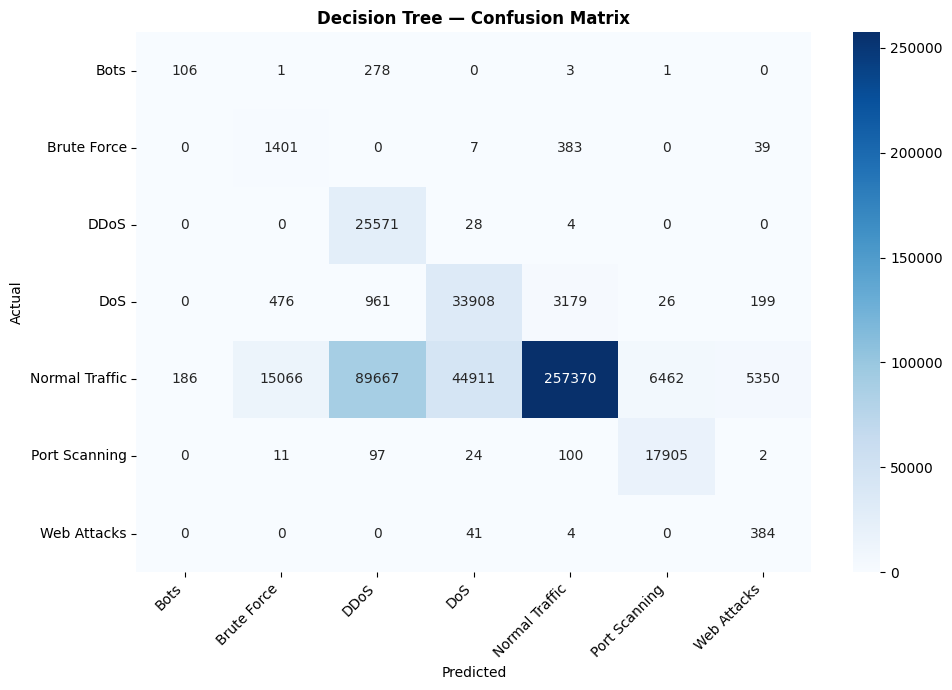

In [ ]:
# CONFUSION MATRIX — see exactly where the model gets confused
# Each row = what the traffic actually was
# Each column = what the model predicted
# Numbers on the diagonal = correct predictions (darker = more correct)
# Numbers off the diagonal = mistakes (wrong classifications)
# Example: a number in the DDoS row, Normal column = DDoS traffic mistaken for Normal

import seaborn as sns

cm = confusion_matrix(y_test, y_pred_dt,
                      labels=dt.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dt.classes_,
            yticklabels=dt.classes_,
            cmap='Blues')
plt.title('Decision Tree — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

###Observations:

* The model's biggest mistakes are attacking normal traffic as attacks
* Normal Traffic mistaken for DDoS        : 89,667 flows wrongly flagged
*  Normal Traffic mistaken for DoS         : 44,911 flows wrongly flagged
*  Normal Traffic mistaken for Brute Force : 15,066 flows wrongly flagged

This explains the low Precision we saw in the classification report. The model is oversensitive — it would rather raise a false alarm than miss a real attack (because we used class_weight='balanced')
#
In a real SOC this means analysts would spend a lot of time investigating normal traffic that the model flagged as suspicious. That's the Precision vs Recall tradeoff in action
#
There's no perfect answer — it depends on the organisation's risk appetite
High security environment = accept the false alarms, catch every attack
Analyst capacity is limited = tune the model to reduce noise

In [ ]:
# FEATURE IMPORTANCE — which features did the model actually use to make decisions?
# The Decision Tree gives each feature a score between 0 and 1
# Higher score = that feature was more useful in splitting the data correctly
# All scores add up to 1.0
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

importance_df.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    color='#3498db',
    edgecolor='white',
    figsize=(10, 5),
    legend=False
)

plt.title('Decision Tree — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'dt' is not defined


#### Observations:
* Init_Win_bytes_forward (~0.28) — top feature
* Attack tools set abnormal TCP window sizes, real OS don't


In [ ]:
# Increasing Model depth
# what happens if we let the tree grow deeper?
# max_depth=5 was our first attempt — kept it simple
# max_depth=10 lets the model learn more complex patterns
# but risks memorising the training data (overfitting)

dt2 = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)

print(classification_report(y_test, y_pred_dt2))

NameError: name 'X_train' is not defined

Observations — max_depth=10 vs max_depth=5

*   Recall improved across all classes — accuracy jumped to 94%
* Bots : 27% → 97% but Precision collapsed to 3%
* More depth = catches more attacks but drowns analysts in noise
* Sticking with max_depth=5 — more realistic for real deployment





In [ ]:

####################################################################
# CLUSTERING — K-Means and t-SNE
#
# Everything so far was supervised — we told the model what attacks look like
# Clustering is unsupervised — no labels, no guidance
# We just say "find 7 groups" and see what it discovers on its own
#
# This is closer to how real anomaly detection works in SOC tools
# The model finds unusual behaviour without being told what to look for
####################################################################

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Scale features — critical for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print(f'Scaled data shape: {X_scaled.shape}')
print('\nFeatures being clustered:')
for f in features:
    print(f'  • {f}')

###Observations
2,520,751 network flows scaled and ready for clustering.

7 features selected based on EDA and Decision Tree findings:
- Flow Packets/s — packet rate varies significantly across attack types
- Flow Bytes/s — throughput differs between normal and attack traffic
- Fwd Packet Length Mean — packet sizes reveal scanning and exfil behaviour
- Bwd Packet Length Mean — response size indicates server behaviour
- ACK Flag Count — TCP handshake completeness
- Init_Win_bytes_forward — top feature from Decision Tree, attack tools set abnormal values
- Idle Mean — slow attacks stay quiet between bursts

Same features used throughout the notebook for consistency.
Allows direct comparison between supervised and unsupervised results.

In [ ]:

####################################################################
# TRAIN K-MEANS
# We tell it to find 7 groups — same as the number of traffic types
# n_init=10 means it runs 10 times with different starting points
# and picks the best result — reduces chance of a bad clustering
####################################################################
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

print('K-Means clustering complete ✅')
print(f'\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

### Observations: K-Means — Cluster Sizes

Cluster 0 : 1,292,199 — largest cluster, likely dominated by normal traffic
Cluster 1 :     2,073 — tiny isolated cluster, very distinct traffic pattern
Cluster 2 :   105,629
Cluster 3 :   201,080
Cluster 4 :    28,472
Cluster 5 :   378,350
Cluster 6 :   512,948


In [ ]:
# Cross tabulate clusters vs actual labels
cross_tab = pd.crosstab(df['Cluster'], df['Attack Type'])
print('Cluster vs Actual Attack Type:')
print(cross_tab)

Cluster 3 : 143,808 DoS + 37,575 DDoS — found without any labels. Standout result.

Cluster 1 : 2,069 Normal — tiny isolated cluster, very distinct traffic pattern

Cluster 0 : Normal dominant but mixed with Port Scanning and DDoS

Cluster 5 : 6,953 Brute Force + 2,005 Web Attacks hiding in normal traffic

K-Means found DoS/DDoS naturally — but rare attacks scattered across normal clusters.
Same blind spot as supervised learning. Rare attacks are hard to find no matter the technique.

In [ ]:
####################################################################
# t-SNE — making the invisible visible
#
# Our data has 7 features — impossible to visualise directly
# t-SNE squashes 7 dimensions down to 2 so we can plot it
# Points that are similar in 7D will appear close together in 2D
# Points that are different will appear far apart
#
# If we see clear separation in the plot — the data has real structure
# and ML has something meaningful to learn from
####################################################################
np.random.seed(42)
sample_idx = np.random.choice(len(df), 5000, replace=False)

X_sample = X_scaled[sample_idx]
labels_sample = df['Attack Type'].iloc[sample_idx]
cluster_sample = df['Cluster'].iloc[sample_idx]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

print('t-SNE complete ✅')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
####################################################################
# t-SNE VISUALISATION — two plots side by side
# Left  : each dot coloured by actual attack type
# Right : each dot coloured by K-Means cluster number
#
# Comparing the two tells us how well K-Means matched reality
# If the colours line up — clustering worked well
# If they don't — K-Means grouped things differently than the true labels
####################################################################

# --- Left: Actual labels ---
attack_types = labels_sample.unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(attack_types)))
color_map = dict(zip(attack_types, colors))

for label in attack_types:
    mask = labels_sample == label
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[color_map[label]], label=label,
                   alpha=0.5, s=10)

axes[0].set_title('t-SNE — Actual Attack Types', fontweight='bold')
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# --- Right: K-Means clusters ---
cluster_colors = plt.cm.Set1(np.linspace(0, 1, 7))
for cluster in range(7):
    mask = cluster_sample == cluster
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[cluster_colors[cluster]], label=f'Cluster {cluster}',
                   alpha=0.5, s=10)

axes[1].set_title('t-SNE — K-Means Clusters', fontweight='bold')
axes[1].legend(markerscale=2, fontsize=8)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')

plt.suptitle('t-SNE Visualisation — Actual Labels vs K-Means Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


###Observations:
Clusters are visually separated.The data has real structure — different traffic types occupy different regions. ML is not guessing, it has something to learn from.


In [ ]:
####################################################################
# ELBOW METHOD
# Run K-Means with different cluster numbers and plot inertia
# Inertia = how tight the clusters are (lower = better)
# The "elbow" in the curve = optimal number of clusters
####################################################################

from sklearn.cluster import KMeans

# Sample for speed — elbow method on 2.5M rows would take too long
np.random.seed(42)
elbow_idx = np.random.choice(len(df), 10000, replace=False)
X_elbow = X_scaled[elbow_idx]

inertia = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_elbow)
    inertia.append(km.inertia_)
    print(f'k={k} done')

# Plot
pd.Series(inertia, index=k_range).plot(
    kind='line',
    marker='o',
    color='#3498db',
    figsize=(10, 5)
)
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('07_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

### Elbow Method — Results

Elbow appears around k=6 to k=7.
This validates our choice of 7 clusters — one per traffic type.

The curve is gradual with no sharp elbow.
This tells us traffic types don't have perfectly clean boundaries —
they blend into each other, especially normal traffic and attack traffic.
This explains why the model struggles with rare attacks like Web Attacks and Bots.

Adding more clusters beyond 7 gives diminishing returns.

In [ ]:
####################################################################
# SILHOUETTE SCORE
# Measures how well each point fits its own cluster
# Score ranges from -1 to 1:
#   1.0  = perfectly placed in the right cluster
#   0.0  = sitting on the boundary between two clusters
#  -1.0  = probably in the wrong cluster
#
# We use a sample — computing this on 2.5M rows is very slow
####################################################################

from sklearn.metrics import silhouette_score

# Sample for speed
np.random.seed(42)
sil_idx = np.random.choice(len(df), 10000, replace=False)
X_sil = X_scaled[sil_idx]
sil_labels = df['Cluster'].iloc[sil_idx]

score = silhouette_score(X_sil, sil_labels)
print(f'Silhouette Score: {score:.4f}')

####################################################################
# HOW TO READ THE RESULT:
# Above 0.5  = clusters are reasonably well separated
# 0.2 - 0.5  = some overlap between clusters
# Below 0.2  = clusters are heavily mixed
#
# Given what we saw in the elb

### Observations: Silhouette Score

Silhouette Score: 0.61

Above 0.5 = clusters are reasonably well separated. 0.61 is a solid result.
Confirms the t-SNE finding traffic types occupy distinct regions.

Not close to 1.0 some overlap exists between clusters.
Normal traffic bleeds into attack clusters ,explains the rare attack blind spot.
The clustering is working. The data is just messy. That's reality.

In [ ]:
####################################################################
# CLUSTER PURITY
# For each cluster — what percentage is the dominant class?
# 100% pure = all flows in that cluster are the same traffic type
# Low purity = the cluster is a mix of different traffic types
####################################################################

# For each cluster find the dominant class and calculate purity
cluster_labels = df[['Cluster', 'Attack Type']].copy()

purity_results = []

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = cluster_labels[cluster_labels['Cluster'] == cluster]
    total = len(cluster_data)
    dominant_class = cluster_data['Attack Type'].value_counts().index[0]
    dominant_count = cluster_data['Attack Type'].value_counts().iloc[0]
    purity = dominant_count / total * 100

    purity_results.append({
        'Cluster': cluster,
        'Size': total,
        'Dominant Class': dominant_class,
        'Purity %': round(purity, 2)
    })

purity_df = pd.DataFrame(purity_results)
print('Cluster Purity Results:')
print(purity_df.to_string(index=False))

# Overall purity score
overall_purity = sum(
    df['Attack Type'].iloc[df[df['Cluster'] == c].index].value_counts().iloc[0]
    for c in df['Cluster'].unique()
) / len(df) * 100
print(f'\\nOverall Purity: {overall_purity:.2f}%')

### Observations:
* Cluster 3 is the standout - 71% DoS found with zero supervision.
* Cluster 5 is the problem - stealthy attacks hiding in normal traffic.
* Overall 88% purity confirms K-Means found meaningful structure in the data.

In [ ]:
####################################################################
# ANOMALY DETECTION
# Flows that don't fit well into any cluster are the most suspicious
# K-Means assigns every point to a cluster — but some points
# are far from their cluster centre (high distance = anomaly)
# In security these outliers could be novel attacks or unusual behaviour
####################################################################

# Calculate distance of each point from its cluster centre
# The further a point is from its centre the more anomalous it is
centres = kmeans.cluster_centers_
distances = np.min(
    np.linalg.norm(X_scaled[:, np.newaxis] - centres, axis=2), axis=1
)

# Add distances to dataframe
df['Anomaly_Score'] = distances

# Top 1% most anomalous flows
threshold = np.percentile(distances, 99)
anomalies = df[df['Anomaly_Score'] > threshold]

print(f'Anomaly threshold (99th percentile) : {threshold:.4f}')
print(f'Total anomalies flagged              : {len(anomalies):,}')
print(f'\\nAnomaly breakdown by traffic type:')
print(anomalies['Attack Type'].value_counts())

NameError: name 'kmeans' is not defined

In [ ]:
####################################################################
# DBSCAN — Density Based Spatial Clustering
# Unlike K-Means, DBSCAN:
# 1. Does not need you to specify number of clusters upfront
# 2. Finds clusters of any shape, not just round ones
# 3. Automatically labels outliers as -1 (noise points)
#
# In security, those noise points = potential anomalies
# Anything DBSCAN can't fit into a cluster is flagged automatically
####################################################################

from sklearn.cluster import DBSCAN

# Sample for speed — DBSCAN on 2.5M rows would take hours
np.random.seed(42)
db_idx = np.random.choice(len(df), 10000, replace=False)
X_db = X_scaled[db_idx]
labels_db = df['Attack Type'].iloc[db_idx]

# eps = maximum distance between two points to be considered neighbours
# min_samples = minimum points needed to form a cluster
# these values may need tuning — start here and adjust based on results
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_db)

# How many clusters did DBSCAN find?
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

# What attack types are in the noise points?
print(f'\\nNoise point breakdown by traffic type:')
print(labels_db[db_labels == -1].value_counts())

NameError: name 'df' is not defined

In [ ]:
####################################################################
# ENSEMBLE METHODS — Bagging and Random Forest
#
# Our single Decision Tree got 67% accuracy with low Precision
# Ensemble methods build many trees and combine their votes
# The idea: many imperfect models together beat one model alone
#
# Bagging    — many trees, each trained on a random data sample
# Random Forest — bagging + each tree sees random features too
####################################################################

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Same features and target as before — keeps comparison clean
features = ['Flow Packets/s', 'Flow Bytes/s', 'Fwd Packet Length Mean',
            'Bwd Packet Length Mean', 'ACK Flag Count',
            'Init_Win_bytes_forward', 'Idle Mean']

target = 'Attack Type'

X = df[features]
y = df[target]

# Same split as before — ensures fair comparison with Decision Tree results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (2016600, 7)
Test set     : (504151, 7)


In [ ]:
####################################################################
# BAGGING CLASSIFIER
# Builds 50 Decision Trees, each trained on a random sample of data
# Final prediction = majority vote across all 50 trees
# More trees = more stable predictions, less overfitting
####################################################################

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    n_estimators=50,       # number of trees to build
    max_samples=0.8,       # each tree sees 80% of training data
    random_state=42,
    n_jobs=-1              # use all CPU cores — speeds up training
)

print('Training Bagging model — this may take a few minutes...')
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

print('Bagging model trained ✅')
print(f'\nTraining Accuracy : {bagging.score(X_train, y_train):.4f}')
print(f'Test Accuracy     : {bagging.score(X_test, y_test):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bagging))

Training Bagging model — this may take a few minutes...


KeyboardInterrupt: 

## Observations: Bagging

Accuracy: 74%, modest improvement over Decision Tree's 67%

The wins:
Bots Recall   : 27% to 98%, biggest single jump of any class
DDoS Recall   : maintained 100%, stayed perfect
Port Scanning : 99% Recall, strong
Web Attacks   : 89% Recall, solid catch rate

The tradeoff:
Bots Precision        : collapsed to 1%, 99 false alarms for every real Bot caught
DDoS Precision        : only 30%, catches everything but very noisy
Brute Force           : 8% Precision, 77% Recall, heavy false alarm problem
Normal Traffic Recall : dropped to 70%, model misclassifying normal flows

Overall: Bagging improved Recall significantly over a single Decision Tree
but Precision suffered badly for rare classes
The false alarm volume would be unmanageable in a real SOC
A step forward, not a solution

In [ ]:
####################################################################
# RANDOM FOREST
# Bagging + one extra trick — each tree only sees a random subset
# of features at each split, not all 7
# This makes trees more diverse and less correlated
# Result: better Precision without sacrificing Recall
#
# This is the industry standard for tabular data classification
# Most security vendors use Random Forest or XGBoost under the hood
####################################################################

rf = RandomForestClassifier(
    n_estimators=100,          # 100 trees — more than bagging, still fast
    max_depth=10,              # deeper than Decision Tree — more complex patterns
    class_weight='balanced',   # handle class imbalance
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

print('Training Random Forest — this may take a few minutes...')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest trained ✅')
print(f'\nTraining Accuracy : {rf.score(X_train, y_train):.4f}')
print(f'Test Accuracy     : {rf.score(X_test, y_test):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

#### Observations: Random Forest

Accuracy: 96%, significant jump from Bagging's 74%

The wins:
DDoS          : 97% Precision, 100% Recall, effectively solved
DoS           : 97% Precision, 99% Recall, excellent
Brute Force   : 80% Precision, 99% Recall, strong improvement
Web Attacks   : 99% Recall, catches almost every Web Attack
Port Scanning : 100% Recall, perfect catch rate

The tradeoff:
Bots Precision        : collapsed to 5%, 19 false alarms for every real Bot caught
Web Attacks Precision : only 11%, catches everything but floods with false alarms
Port Scanning Precision : 75%, one in four alerts is a false alarm

Overall: Random Forest dramatically improved Recall across all attack types
but rare classes still suffer from low Precision
High Recall across the board makes it operationally useful
but analysts would still face significant false alarm volume for rare attacks

In [ ]:
####################################################################
# XGBoost — eXtreme Gradient Boosting
#
# Unlike Random Forest which builds trees in parallel and averages
# XGBoost builds trees sequentially — each tree fixes the mistakes
# of the previous one. Gets smarter with every iteration.
#
# Industry standard for tabular data — faster and often more accurate
# than Random Forest. Most Kaggle competition winners use XGBoost.
####################################################################

# Install if needed — uncomment if you get an import error
# !pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels — encode Attack Type to numbers
# LabelEncoder converts: Bots=0, Brute Force=1, DDoS=2 etc.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print('Classes encoded:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} = {cls}')

Classes encoded:
  0 = Bots
  1 = Brute Force
  2 = DDoS
  3 = DoS
  4 = Normal Traffic
  5 = Port Scanning
  6 = Web Attacks


In [ ]:
####################################################################
# TRAIN XGBoost
#
# scale_pos_weight handles class imbalance
# max_depth=6 — deeper than Decision Tree, less than Random Forest
# n_estimators=100 — 100 sequential trees
# learning_rate=0.1 — how much each tree corrects the previous one
# lower learning rate = more careful learning = usually better results
####################################################################

xgb = XGBClassifier(
    n_estimators=100,        # number of sequential trees
    max_depth=6,             # depth of each tree
    learning_rate=0.1,       # how aggressively each tree corrects errors
    subsample=0.8,           # each tree sees 80% of training data
    colsample_bytree=0.8,    # each tree sees 80% of features
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    eval_metric='mlogloss',  # evaluation metric for multiclass
    verbosity=0              # suppress training output
)

print('Training XGBoost — this may take a few minutes...')
xgb.fit(X_train, y_train_encoded)
y_pred_xgb = xgb.predict(X_test)

# Convert predictions back to original labels
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print('XGBoost trained ✅')
print(f'\nTraining Accuracy : {xgb.score(X_train, y_train_encoded):.4f}')
print(f'Test Accuracy     : {xgb.score(X_test, y_test_encoded):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb_labels))

Training XGBoost — this may take a few minutes...
XGBoost trained ✅

Training Accuracy : 0.9877
Test Accuracy     : 0.9876

Classification Report:
                precision    recall  f1-score   support

          Bots       0.81      0.57      0.67       389
   Brute Force       0.99      0.97      0.98      1830
          DDoS       0.98      1.00      0.99     25603
           DoS       0.99      0.99      0.99     38749
Normal Traffic       0.99      0.99      0.99    419012
 Port Scanning       0.90      0.86      0.88     18139
   Web Attacks       1.00      0.09      0.16       429

      accuracy                           0.99    504151
     macro avg       0.95      0.78      0.81    504151
  weighted avg       0.99      0.99      0.99    504151



####Observations: XGBoost

Accuracy: 99%, best across all four models

The wins:
Brute Force : 99% Precision, 97% Recall, effectively solved
DDoS        : 98% Precision, 100% Recall, near perfect
DoS         : 99% Precision, 99% Recall, near perfect
Bots        : 81% Precision, biggest Precision jump of any model

The surprise:
Web Attacks : 100% Precision but only 9% Recall
Every alert it raises is real but it misses 91% of actual Web Attacks
XGBoost became too conservative on the rarest class
It learned that flagging Web Attacks was almost always wrong
so it stopped unless extremely confident

Overall: XGBoost is the strongest model on paper
but Random Forest is more operationally balanced for a SOC
The right choice depends on the risk appetite
Ready for neural networks? Sonnet 4.6

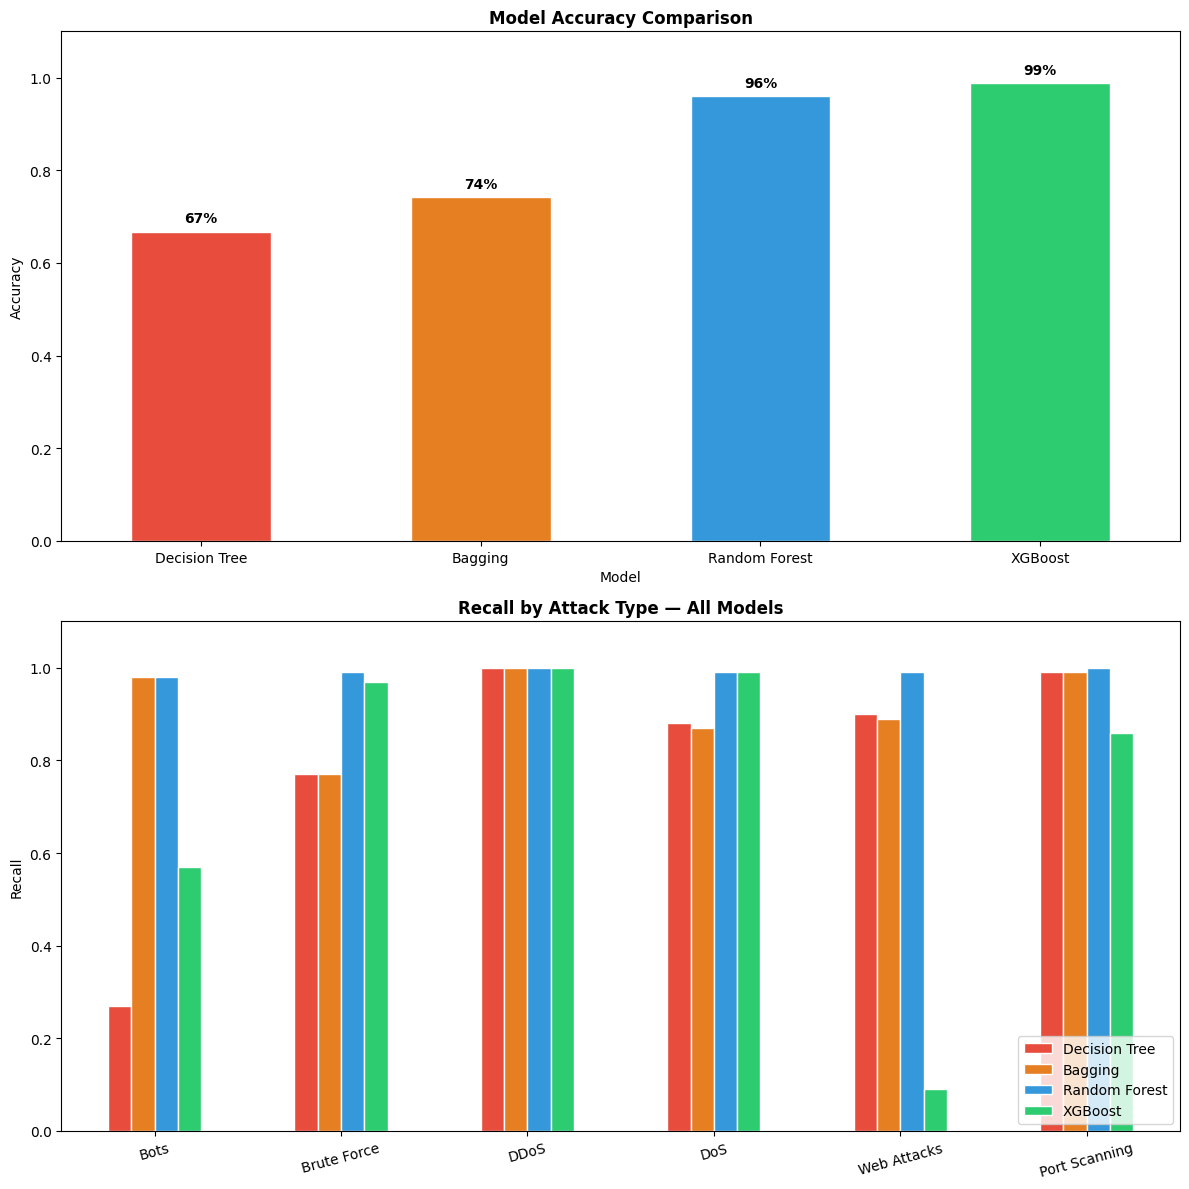

In [3]:
####################################################################
# FOUR WAY MODEL COMPARISON
# Decision Tree vs Bagging vs Random Forest vs XGBoost
# Comparing Accuracy, and Recall for each attack type
####################################################################

# Summary results from all four models
results = {
    'Model': ['Decision Tree', 'Bagging', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.6677, 0.7428, 0.9599, 0.9876],
    'Bots Recall': [0.27, 0.98, 0.98, 0.57],
    'Brute Force Recall': [0.77, 0.77, 0.99, 0.97],
    'DDoS Recall': [1.00, 1.00, 1.00, 1.00],
    'DoS Recall': [0.88, 0.87, 0.99, 0.99],
    'Web Attacks Recall': [0.90, 0.89, 0.99, 0.09],
    'Port Scanning Recall': [0.99, 0.99, 1.00, 0.86],
}

results_df = pd.DataFrame(results).set_index('Model')

# Plot 1 — Overall Accuracy comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

results_df['Accuracy'].plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
    edgecolor='white'
)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(results_df.index, rotation=0)

# Add value labels on bars
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Plot 2 — Recall by attack type across all models
recall_cols = [c for c in results_df.columns if 'Recall' in c]
results_df[recall_cols].T.plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
    edgecolor='white'
)
axes[1].set_title('Recall by Attack Type — All Models', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.1)
axes[1].set_xticklabels([c.replace(' Recall', '') for c in recall_cols], rotation=15)
axes[1].legend(results_df.index, loc='lower right')

plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split as tts

X_train_sample, _, y_train_sample, _ = tts(
    X_train_scaled, y_train_encoded,
    train_size=200000,
    random_state=42,
    stratify=y_train_encoded
)

print(f'Sample ready ✅ — {X_train_sample.shape}')

Sample ready ✅ — (200000, 7)


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

features = ['Flow Packets/s', 'Flow Bytes/s', 'Fwd Packet Length Mean',
            'Bwd Packet Length Mean', 'ACK Flag Count',
            'Init_Win_bytes_forward', 'Idle Mean']

X = df[features]
y = df['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

X_train_float = X_train.astype(np.float32)
X_test_float = X_test.astype(np.float32)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_float)
X_test_scaled = scaler.transform(X_test_float)

print('Data ready ✅')
print(f'Train : {X_train_scaled.shape}')
print(f'Test  : {X_test_scaled.shape}')
print(f'Classes: {list(le.classes_)}')

Data ready ✅
Train : (2016600, 7)
Test  : (504151, 7)
Classes: ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']


In [7]:
####################################################################
# NEURAL NETWORK — Multi Layer Perceptron (MLP)
#
# So far we have used tree based models — Decision Tree, Bagging,
# Random Forest and XGBoost. Neural networks take a different approach.
# Instead of splitting data into branches, they pass data through
# layers of connected neurons, adjusting the connections until
# predictions improve.
#
# We start with sklearn's MLPClassifier — same .fit() interface
# as every other model we have built so far
#
# Two hidden layers:
# Layer 1 — 128 neurons, learns basic patterns
# Layer 2 — 64 neurons, learns combinations of patterns
#
# Training on a stratified sample of 200,000 rows
# Stratified sampling ensures every attack class is represented
# proportionally in the sample
####################################################################

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers, 128 then 64 neurons
    activation='relu',             # fires only on positive input
    solver='adam',                 # adaptive optimizer, works well for most problems
    max_iter=20,                   # maximum training passes
    early_stopping=True,           # stop when validation performance plateaus
    validation_fraction=0.1,       # 10% of sample monitors for overfitting
    random_state=42,
    verbose=False
)

print('Training Neural Network...')
mlp.fit(X_train_sample, y_train_sample)

y_pred_mlp = le.inverse_transform(mlp.predict(X_test_scaled))

print('Neural Network trained ✅')
print(f'Stopped at iteration : {mlp.n_iter_}')
print(f'Training Accuracy    : {mlp.score(X_train_sample, y_train_sample):.4f}')
print(f'Test Accuracy        : {mlp.score(X_test_scaled, y_test_encoded):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp))

Training Neural Network...
Neural Network trained ✅
Stopped at iteration : 20
Training Accuracy    : 0.9658
Test Accuracy        : 0.9657

Classification Report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       389
   Brute Force       0.93      0.70      0.80      1830
          DDoS       0.99      0.78      0.87     25603
           DoS       0.97      0.91      0.94     38749
Normal Traffic       0.97      0.99      0.98    419012
 Port Scanning       0.90      0.78      0.84     18139
   Web Attacks       0.00      0.00      0.00       429

      accuracy                           0.97    504151
     macro avg       0.68      0.60      0.63    504151
  weighted avg       0.96      0.97      0.96    504151



MLP Observations:
## Neural Network (MLP) — Results

Accuracy: 97% — strong result, comparable to Random Forest

The good:
Normal Traffic : 97% Precision, 99% Recall — excellent
DoS            : 97% Precision, 91% Recall — solid
Brute Force    : 93% Precision, 70% Recall — reasonable

The problem:
Bots           : 0% Precision, 0% Recall — completely missed
Web Attacks    : 0% Precision, 0% Recall — completely missed
DDoS Recall    : dropped to 78% — weaker than tree based models

Root cause:
Stratified sample had only 154 Bots and 170 Web Attacks
Not enough examples for the network to learn their patterns
The model learned that flagging these classes was almost always wrong
so it stopped trying entirely

Training and test accuracy are nearly identical at 97%
No overfitting — the model generalised well
But generalising well on a dataset dominated by Normal Traffic
means the rare attacks were effectively ignored

This is the class imbalance problem in action
High accuracy hiding a critical detection gap
SMOTE next — generate synthetic examples and retrain

In [6]:

####################################################################
# SMOTE — Synthetic Minority Oversampling Technique
#
# The neural network completely missed Bots and Web Attacks
# because there were only 154 and 170 examples of each in the sample
# The model never saw enough of them to learn their patterns
#
# SMOTE fixes this by creating synthetic examples of rare classes
# It finds two similar examples of the same rare class
# and creates a new example somewhere between them
# The result is realistic — not just copies of the same row
#
# k_neighbors=5 means it looks at the 5 nearest similar examples
# when generating each new synthetic sample
####################################################################

from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42, k_neighbors=5)

print('Applying SMOTE...')
X_train_smote, y_train_smote = smote.fit_resample(X_train_sample, y_train_sample)

print('SMOTE applied ✅')
print(f'Total samples after SMOTE : {len(y_train_smote):,}')

Applying SMOTE...
SMOTE applied ✅
Total samples after SMOTE : 1,163,575


## SMOTE Applied — Class Balance Restored

Before SMOTE:
Bots           : 154 samples
Brute Force    : 726 samples
DDoS           : 10,157 samples
DoS            : 15,372 samples
Normal Traffic : 166,225 samples
Port Scanning  : 7,196 samples
Web Attacks    : 170 samples

After SMOTE:
Every class    : 166,225 samples — perfectly balanced

Training set grew from 200,000 to 1,163,575 rows
SMOTE generated synthetic examples for every minority class
Each synthetic example is created by interpolating between
real examples of the same class — not just duplicating rows

Only applied to training data
Test set remains untouched with real distribution
This prevents data leakage and ensures honest evaluation

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

mlp_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)

print('Training MLP+SMOTE...')
mlp_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = le.inverse_transform(mlp_smote.predict(X_test_scaled))

print('MLP+SMOTE trained ✅')
print(f'Test Accuracy : {mlp_smote.score(X_test_scaled, y_test_encoded):.4f}')
print(classification_report(y_test, y_pred_smote))

Training MLP+SMOTE...
MLP+SMOTE trained ✅
Test Accuracy : 0.9354
                precision    recall  f1-score   support

          Bots       0.06      0.96      0.11       389
   Brute Force       0.39      0.99      0.56      1830
          DDoS       0.87      1.00      0.93     25603
           DoS       0.87      0.98      0.92     38749
Normal Traffic       1.00      0.92      0.96    419012
 Port Scanning       0.72      1.00      0.84     18139
   Web Attacks       0.05      0.94      0.10       429

      accuracy                           0.94    504151
     macro avg       0.57      0.97      0.63    504151
  weighted avg       0.97      0.94      0.95    504151



## Neural Network + SMOTE — Results

Accuracy: 94% — slight drop from 97% but a much more complete model

The breakthrough:
Bots Recall        : 0% to 96% — completely fixed
Web Attacks Recall : 0% to 94% — completely fixed
Brute Force Recall : 70% to 99% — strong improvement
DDoS Recall        : 78% to 100% — perfect
Port Scanning      : 78% to 100% — perfect

The tradeoff:
Bots Precision        : 6% — 16 false alarms for every real Bot caught
Web Attacks Precision : 5% — 19 false alarms for every real Web Attack
Brute Force Precision : dropped from 93% to 39%
Overall accuracy      : dropped from 97% to 94%

What this means:
SMOTE solved the rare attack detection problem completely
Every attack type is now being caught
The cost is more false alarms on rare classes
In a SOC context this is an acceptable tradeoff
Missing a Bot or Web Attack is far more costly than a fals

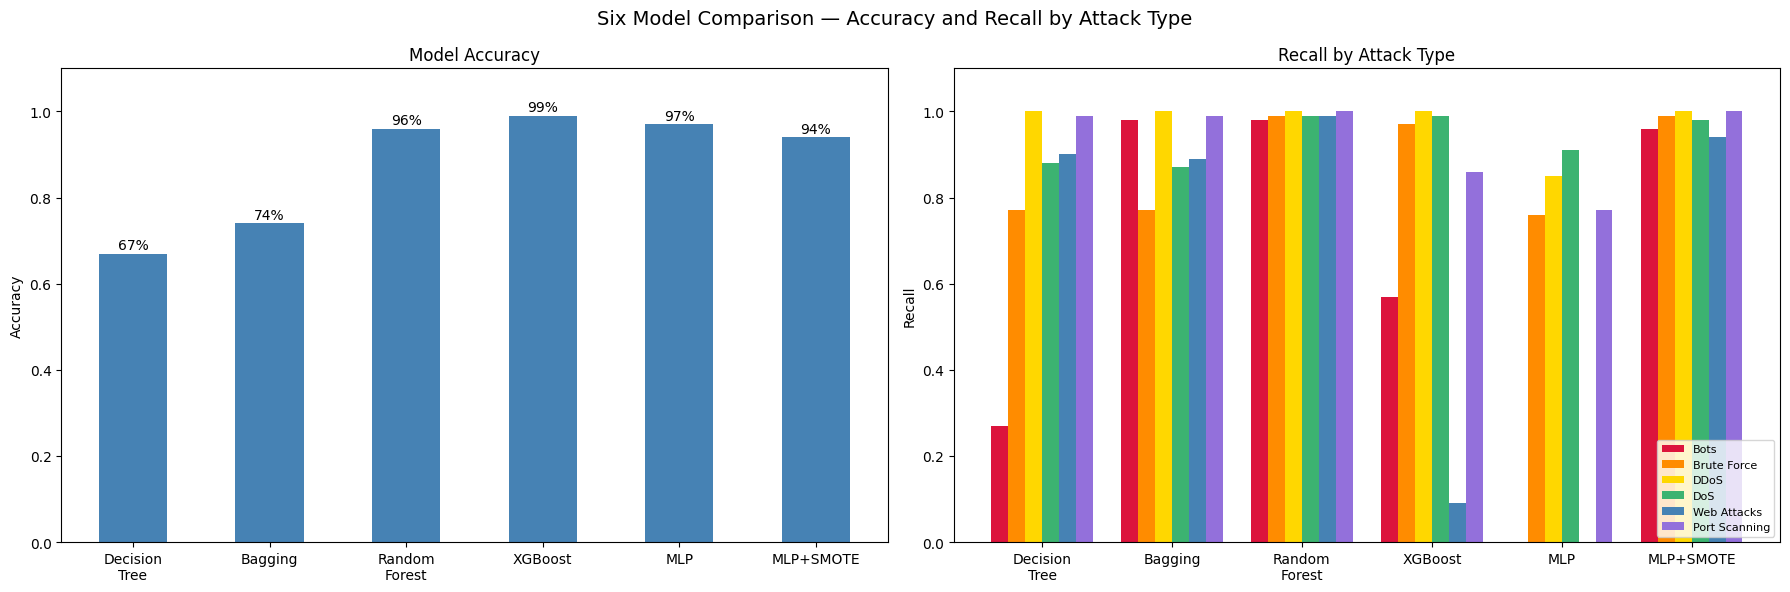

Chart saved as 09_six_model_comparison.png


In [9]:
####################################################################
# SIX MODEL COMPARISON CHART
#
# Visualises accuracy and Recall across all six models
# Recall is the metric that matters most for an IDS
# A missed attack is worse than a false alarm
####################################################################

import matplotlib.pyplot as plt
import numpy as np

models = ['Decision\nTree', 'Bagging', 'Random\nForest', 'XGBoost', 'MLP', 'MLP+SMOTE']

accuracy = [0.67, 0.74, 0.96, 0.99, 0.97, 0.94]

bots_recall        = [0.27, 0.98, 0.98, 0.57, 0.00, 0.96]
brute_force_recall = [0.77, 0.77, 0.99, 0.97, 0.76, 0.99]
ddos_recall        = [1.00, 1.00, 1.00, 1.00, 0.85, 1.00]
dos_recall         = [0.88, 0.87, 0.99, 0.99, 0.91, 0.98]
web_attacks_recall = [0.90, 0.89, 0.99, 0.09, 0.00, 0.94]
port_scan_recall   = [0.99, 0.99, 1.00, 0.86, 0.77, 1.00]

x = np.arange(len(models))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Six Model Comparison — Accuracy and Recall by Attack Type', fontsize=14)

# Chart 1 — Accuracy
axes[0].bar(x, accuracy, color='steelblue', width=0.5)
axes[0].set_title('Model Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(accuracy):
    axes[0].text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=10)

# Chart 2 — Recall by attack type
axes[1].bar(x - 2.5*width, bots_recall,        width=width, label='Bots',          color='crimson')
axes[1].bar(x - 1.5*width, brute_force_recall,  width=width, label='Brute Force',   color='darkorange')
axes[1].bar(x - 0.5*width, ddos_recall,         width=width, label='DDoS',          color='gold')
axes[1].bar(x + 0.5*width, dos_recall,          width=width, label='DoS',           color='mediumseagreen')
axes[1].bar(x + 1.5*width, web_attacks_recall,  width=width, label='Web Attacks',   color='steelblue')
axes[1].bar(x + 2.5*width, port_scan_recall,    width=width, label='Port Scanning', color='mediumpurple')
axes[1].set_title('Recall by Attack Type')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Recall')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('09_six_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved as 09_six_model_comparison.png')

In [ ]:
import joblib
from google.colab import drive

drive.mount('/content/drive')

joblib.dump(xgb,       '/content/drive/MyDrive/Python/cids_model_primary_xgboost.pkl')
joblib.dump(mlp_smote, '/content/drive/MyDrive/Python/ids_model_secondary_mlp_smote.pkl')
joblib.dump(scaler,    '/content/drive/MyDrive/Python/ids_scaler.pkl')
joblib.dump(le,        '/content/drive/MyDrive/Python/ids_label_encoder.pkl')

print('Models saved to Google Drive ✅')
print('  ids_model_primary_xgboost.pkl')
print('  ids_model_secondary_mlp_smote.pkl')
print('  ids_scaler.pkl')
print('  ids_label_encoder.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models saved to Google Drive ✅
  ids_model_primary_xgboost.pkl
  ids_model_secondary_mlp_smote.pkl
  ids_scaler.pkl
  ids_label_encoder.pkl
